# 02 — Exploratory Data Analysis
**Project:** Retail Sales Intelligence Platform  
**Dataset:** Global Superstore (Kaggle)  
**Purpose:** Answer 6 business questions through grouped analysis to identify trends in sales, profit, regional performance, discount impact, and shipping — feeding directly into the Power BI dashboard design.

## Business Questions Covered
1. Yearly sales and profit trend
2. Category and sub-category performance
3. Regional performance
4. Customer segment analysis
5. Discount impact on profit
6. Shipping analysis

In [37]:
# ── Imports ──────────────────────────────────────────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [38]:
# ── Load clean data ───────────────────────────────────────────────────────

DATA_PATH = os.path.join('..', 'data', 'processed', 'cleaned_superstore.csv')
df = pd.read_csv(DATA_PATH, encoding='latin-1',parse_dates=['order_date', 'ship_date'])
print(df.shape)
print(df.head(3))

(51290, 30)
          category         city        country customer_id     customer_name  \
0  Office Supplies  Los Angeles  United States   LS-172304  Lycoris Saunders   
1  Office Supplies  Los Angeles  United States   MV-174854     Mark Van Huff   
2  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   

   discount market order_date        order_id order_priority  ...  \
0       0.0     US 2011-01-07  CA-2011-130813           High  ...   
1       0.0     US 2011-01-21  CA-2011-148614         Medium  ...   
2       0.0     US 2011-08-05  CA-2011-118962         Medium  ...   

  shipping_cost       state  sub_category  year        market2  weeknum  \
0          4.37  California         Paper  2011  North America        2   
1          0.94  California         Paper  2011  North America        4   
2          1.81  California         Paper  2011  North America       32   

   days_to_ship order_month order_quarter profit_margin_pct  
0             2           1

## 1. Yearly Sales and Profit Trend

In [42]:
# ── Yearly Sales and Profit Trend ─────────────────────────────────────────

yearly_sales = df.groupby('year').agg(total_sales= ('sales','sum'),
                                    total_profit = ('profit','sum'))

print(yearly_sales)

      total_sales  total_profit
year                           
2011      2259511  248940.81154
2012      2677493  307415.27910
2013      3405860  406935.23018
2014      4300041  504165.97046


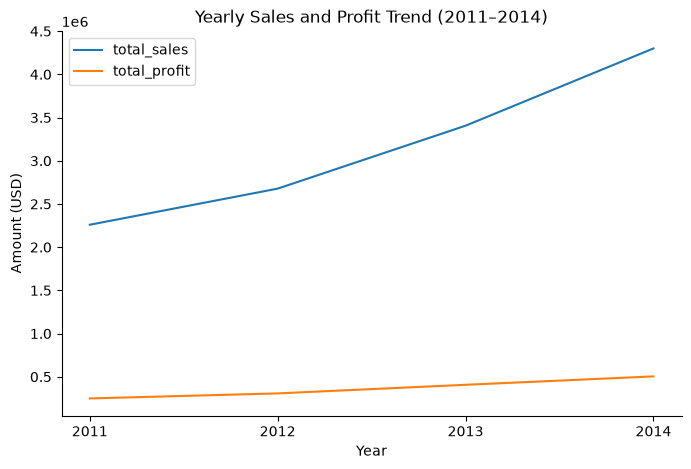

In [ ]:
# ── Plotting Line Chart ─────────────────────────────────────────

yearly_sales.plot(
    y=['total_sales','total_profit'],
                  figsize=(8,5)
                  )
plt.xticks([2011,2012,2013,2014])
plt.title('Yearly Sales and Profit Trend (2011–2014)')
plt.xlabel('Year')
plt.ylabel('Amount (USD)')
plt.show()

Sales grew consistently from $2.3M in 2011 to $4.5M in 2014, a 90% increase over four years. Profit followed the same trajectory, rising from $249K to $504K. However, profit grew at a slower rate than sales, suggesting margin pressure that warrants further investigation at the category level.


## 2. Category and sub-category performance

In [47]:
# ── Category performance ─────────────────────────────────────────

category_performance = df.groupby('category').agg(total_sales = ('sales', 'sum'),
                                            total_profit = ('profit','sum'),
                                            avg_profit_margin = ('profit_margin_pct', 'mean')
)


print(category_performance)



                 total_sales  total_profit  avg_profit_margin
category                                                     
Furniture            4110884  285204.72380           0.870491
Office Supplies      3787330  518473.83430           5.855940
Technology           4744691  663778.73318           4.965905


In [ ]:
# ── Sub-category Performance ─────────────────────────────────────────

sub_category_performance = df.groupby('sub_category').agg(total_sales = ('sales','sum'),
                                                    total_profit = ('profit', 'sum'),
                                                    avg_profit_margin = ('profit_margin_pct','mean'))



print(sub_category_performance.sort_values('total_profit',ascending=True))

              total_sales  total_profit  avg_profit_margin
sub_category                                              
Tables             757034  -64083.38870         -24.209907
Fasteners           83254   11525.42410           5.514132
Labels              73433   15010.51200          11.918285
Supplies           243090   22583.26310           4.376953
Envelopes          170926   29601.11630           8.996669
Furnishings        385609   46967.42550           5.470833
Art                372163   57953.91090           6.579754
Machines           779071   58867.87300          -4.340754
Paper              244307   59207.68270          19.697747
Binders            461952   72449.84600          -0.297038
Storage           1127124  108461.48980           1.268612
Accessories        749307  129626.30620           8.698465
Chairs            1501682  140396.26750           2.481243
Appliances        1011081  141680.58940          -0.118244
Bookcases         1466559  161924.41950           1.4842

Four sub-categories are loss-making: Tables (-24.2%), Machines (-4.3%), Binders (-0.3%), and Appliances (-0.1%). Despite being the second highest revenue category at $4.1M, Furniture has the thinnest overall margin at just 0.87%, largely driven down by Tables. Paper is the standout performer with the highest margin at 19.7%.

## 3. Regional performance

In [51]:
# ── Regional Performance ──────────────────────────────────────────────────────────────

regional_performance = df.groupby('region').agg(total_sales = ('sales','sum'),
                                                         total_profit = ('profit','sum'),
                                                         avg_profit_margin = ('profit_margin_pct','mean'))

print(regional_performance.sort_values('total_profit',ascending=False))

                total_sales  total_profit  avg_profit_margin
region                                                      
Central             2822399  311403.98164           6.009063
North               1248192  194597.95252          12.521611
North Asia           848349  165578.42100          17.952070
South               1600960  140355.76618           5.344248
Central Asia         752839  132480.18700          14.698667
Oceania             1100207  120089.11200           8.350123
West                 725514  108418.44890          21.944027
East                 678834   91522.78000          16.716942
Africa               783776   88871.63100         -14.509148
EMEA                 806184   43897.97100         -14.161829
Caribbean            324281   34571.32104           8.118219
Southeast Asia       884438   17852.32900          -7.886903
Canada                66932   17817.39000          24.743099


Central region generates the highest total profit but at a moderate margin of 6%. Canada is the most efficient region — lowest sales at $66.9K yet one of the highest margins at ~25%. Africa, Southeast Asia, and EMEA are the three loss-making regions with negative profit margins.

## 4. Customer Segment Analysis

In [50]:
# ── Customer Segment Analysis ──────────────────────────────────────────────────────────────

segment_performance = df.groupby('segment').agg( total_sales = ('sales','sum'),
                                             total_profit = ('profit', 'sum'),
                                             avg_profit_margin = ('profit_margin_pct','mean')
)


print(segment_performance.sort_values('total_profit', ascending=False))

             total_sales  total_profit  avg_profit_margin
segment                                                  
Consumer         6508141  749239.78206           4.616207
Corporate        3824808  441208.32866           4.564506
Home Office      2309956  277009.18056           5.271265


Consumer is the largest segment by both revenue ($6.5M) and total profit ($749K), though all three segments have similar average margins between 4.6% and 5.3%. Home Office has the highest margin at 5.27% despite the lowest revenue at $2.3M. No segment is loss-making — the profitability challenge in this dataset lies at the sub-category level, not the customer segment level.

## 5. Discount impact on profit

In [54]:
# ── Creating Discount Band ──────────────────────────────────────────────────────────────
 
group_name = ['No Discount','0-10%','10-30%','30-50%','>50%']
edges = [0, 0.001, 0.1, 0.3, 0.5, 1.0]

df["discount_band"] = pd.cut(df['discount'],bins=edges, labels=group_name, include_lowest=True)



In [55]:
# ── Discount Impact on Profits ──────────────────────────────────────────────────────────────

discount_band_performance = df.groupby('discount_band',observed=True).agg(avg_profit_margin = ('profit_margin_pct', 'mean'),
                                          total_profit = ('profit','sum'))
                           


print(discount_band_performance.sort_values('discount_band',ascending=True))

               avg_profit_margin  total_profit
discount_band                                 
No Discount            26.482676  1.770695e+06
0-10%                  17.132981  3.381893e+05
10-30%                 11.409768  1.520992e+05
30-50%                -33.788783 -3.809448e+05
>50%                 -115.036528 -4.125817e+05


Orders with no discount yield the highest average profit margin at 26.5% and generate the most total profit at $1.77M. As discounts increase, margins deteriorate sharply — orders with discounts above 50% carry an average margin of -115%, resulting in a total loss of $413K. Discounting beyond 30% is consistently loss-making.

## 6. Shipping analysis

In [57]:
# ── Shipping Analysis ──────────────────────────────────────────────────────────────

shipping_performance = df.groupby('ship_mode').agg(total_sales = ('sales','sum'),
                                                      avg_shipping_cost = ('shipping_cost','mean'),
                                                      avg_days_to_ship = ('days_to_ship','mean'))


print(shipping_performance.sort_values('avg_shipping_cost',ascending=False))

                total_sales  avg_shipping_cost  avg_days_to_ship
ship_mode                                                       
Same Day             667202          42.937325          0.037394
First Class         1831067          41.052970          2.181746
Second Class        2565747          30.469666          3.230187
Standard Class      7578889          19.971654          4.998018


Same Day is the most expensive shipping mode at ~$43 per order but delivers in under a day. Standard Class costs roughly half at ~$20 per order but takes ~5 days. Whether the Same Day premium is justified depends on the customer segment and order value.